# Interactive Teaching Enhancements
## Learning Objectives
- Live Coding
- Pair Programming
- Mini Challenge
- Debugging Exercise
- AI Prompt Box
- Reflection

### 👥 Pair Programming
Student A writes code, Student B reviews, then switch.

### 🚧 Live Coding
Start from an empty cell and build the solution together.

### 🐞 Debugging Challenge
Purposely break one line of code and ask students to fix it.

### 🤖 AI Prompt
Ask ChatGPT to improve the solution, then verify it.

### 📝 Reflection
What did you learn? What would you improve?


# Google Colab Path Note

If you run this notebook in Google Colab, mount Google Drive first:

```python
from google.colab import drive
drive.mount('/content/drive')
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/UCI/UCI_427.62_Python_for_Data_Analysis'
DATA_DIR = f'{BASE_DIR}/05_Datasets'
ASSIGNMENTS_DIR = f'{BASE_DIR}/04_Assignments'
OUTPUTS_DIR = f'{BASE_DIR}/04_Assignments/Outputs'
```

If you run locally in Jupyter/Anaconda, do not use `/content/drive`; use relative paths such as `../05_Datasets/...`.
The Mac path `/Users/yuzhang/.../My Drive/...` is only for local file browsing and is not a Colab path.


# Plotting with Pandas

## Notebook Outline
* [Introduction To Plotting](#introtoplotting)
* [Line Plots](#lineplots)
* [Histograms](#histograms)
* [Bar Charts](#barcharts)

<a name='introtoplotting'></a>
# Introduction to Plotting
Mastering plotting in Python is not easy (unfortunately) there are multiple ways to do just about everything, and fine tuning can be complex.  The most commonly used python plotting library is matplotlib.  It gives you _a lot_ of control over plots but the control comes with the price of complexity.

Seaborn is a very popular python plotting that is more aesthetically pleasing than matplotlib and provides easier access to some functionality. It is built on top of matplotlib (which is one reason why we will cover matplotlib below).  I recommend that, if you are interested, you check out seaborn here: <https://seaborn.pydata.org/>

There is a great online gallery of matplotlib graphs here <https://python-graph-gallery.com/> with examples and code. It is a great resource in continuing to learn about data visualization in Python.

We are going to cover matplotlib below because the other libraries, like seaborn, are all built on top of it, and I believe you have to have an understanding (to some degree) of matplotib to successfully plot data with Python.

Remember that there a multiple ways to create these plots. I am showing you the methods that I usually use that I think is area good balance between simplicity and control.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Line Plots
Let's look at a typical line plot.  We will use our fuel price data set, that we used in a previous week, for this plot.  First, let's load in the data and take a look at it using head() and info().

In [ ]:
fuelPrices = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/UCI/UCI_427.62_Python_for_Data_Analysis/05_Datasets/M3_AAA_Fuel_Prices.csv',
                        parse_dates=[0])

/tmp/ipykernel_976/1030835728.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  fuelPrices = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/UCI/UCI_427.62_Python_for_Data_Analysis/Data/AAA_Fuel_Prices.csv',


In [ ]:
fuelPrices.head()

,Month_of_Price,County,Fuel,Price,PhysicalUnit
0,2006-01-01,US,Gasoline - Regular,2.314,Dollars
1,2006-01-01,US,Gasoline - Midgrade,2.457,Dollars
2,2006-01-01,US,Gasoline - Premium,2.546,Dollars
3,2006-01-01,US,Diesel,2.568,Dollars
4,2006-01-01,State of Hawaii,Gasoline - Regular,2.800,Dollars


In [ ]:
fuelPrices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1580 entries, 0 to 1579
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Month_of_Price  1580 non-null   datetime64[ns]
 1   County          1580 non-null   object        
 2   Fuel            1580 non-null   object        
 3   Price           1580 non-null   float64       
 4   PhysicalUnit    1580 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 61.8+ KB


#### We'd like to plot the price for regular grade gasoline in the US.
Let's first grab that data from the dataframe.

In [ ]:
USRegular = fuelPrices.loc[(fuelPrices['County']=='US') &
                           (fuelPrices['Fuel'] == 'Gasoline - Regular'), :]

#### Now, let's plot the data:

#### Introducing plt.subplots()

The first thing we want to do is create our figure and axis.  The figure is the entire canvas that the plot is created on.  The axis is just one area of the canvas that plots particular data.  So, if you have 4 subplots on one figure, you would have 4 axes. If you just have one plot on your figure, then you have one axis.

We create the figure and axis (or axes) using the subplots() method of the pyplot sub-module of the matplotlib python library. The first two arguments are the number of rows and number of columns of the axes layout that we want. Let's see some examples of this.

<class 'matplotlib.figure.Figure'>
<class 'numpy.ndarray'>
(2, 2)
<class 'matplotlib.axes._axes.Axes'>


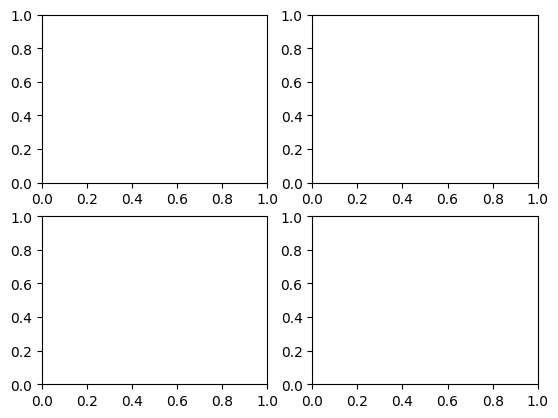

In [ ]:
fig, axs = plt.subplots(2, 2)
print(type(fig))
print(type(axs))
print(axs.shape)
print(type(axs[0, 0]))

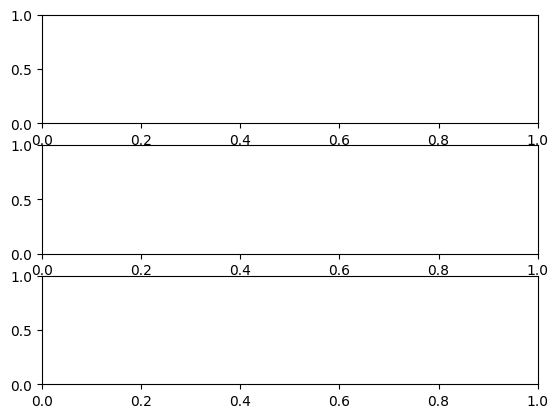

In [ ]:
fig, axs = plt.subplots(3, 1)

<class 'matplotlib.figure.Figure'>
<class 'matplotlib.axes._axes.Axes'>


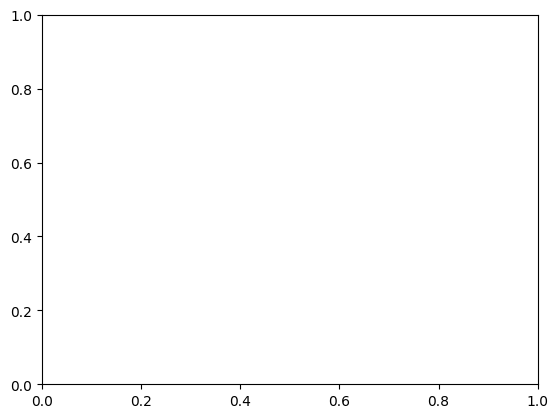

In [ ]:
fig, axs = plt.subplots(1, 1)
print(type(fig))
print(type(axs))

#### Introducing the plot() method of a dataframe (or series)
Now that we have created our figure and axes, we are ready to plot our data.  Just select the column of data you'd like to plot (in this case the 'Price') column and call the plot() method. Also, pass the axis that you'd like the data plotted on to the ax argument.

<Axes: >

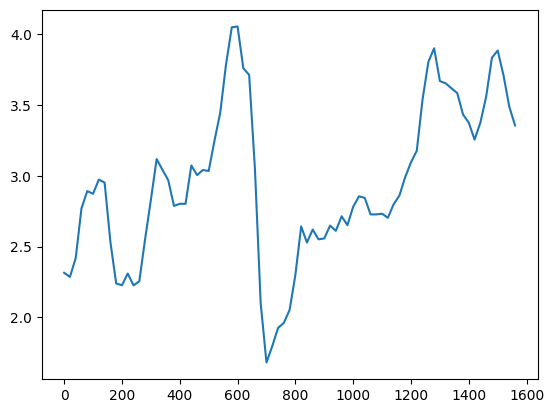

In [ ]:
fig, axs = plt.subplots(1, 1)
USRegular['Price'].plot(ax=axs)

#### Introducing the figsize argument to set the figure size
Set figsize to a tuple. The first entry controls the height and the second controls the width.

<Axes: >

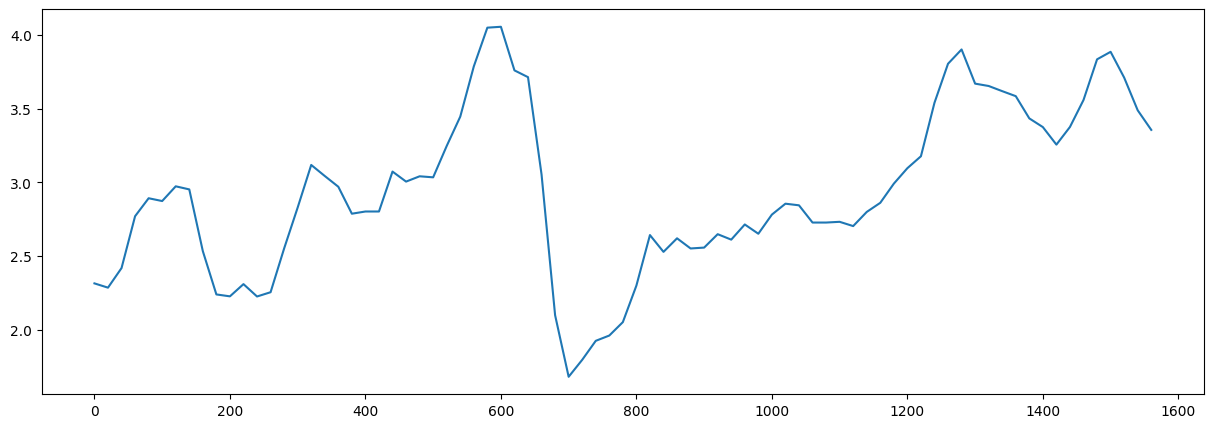

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(15, 5))
USRegular['Price'].plot(ax=axs)

#### Introducting the set_xlabel(), set_ylabel(), and set_title() methods

Text(0.5, 1.0, 'Fuel Price In The US')

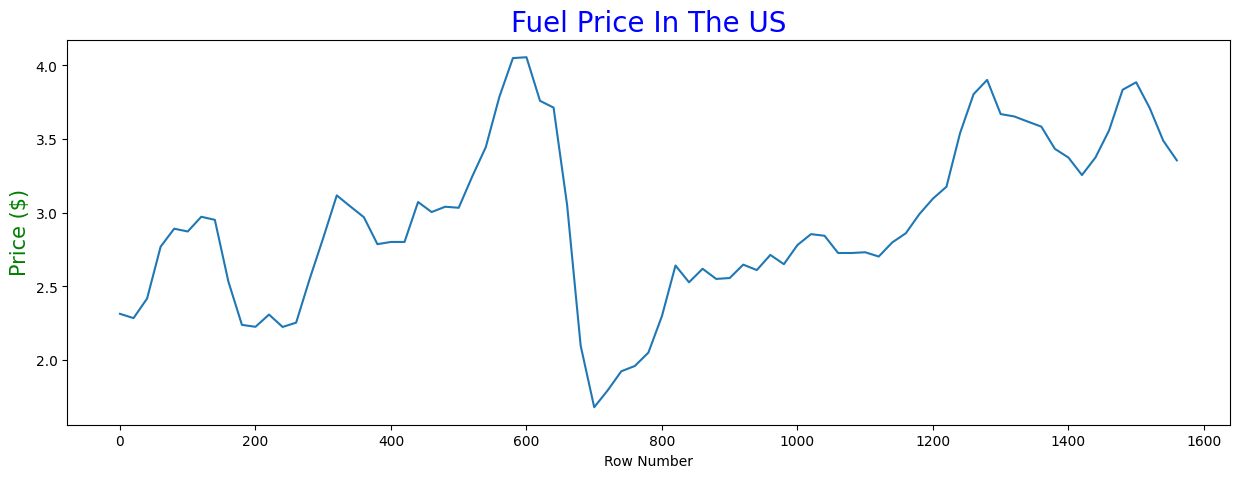

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(15, 5))
USRegular['Price'].plot(ax=axs)
axs.set_xlabel('Row Number')
axs.set_ylabel('Price ($)', color='green', fontsize=15)
axs.set_title('Fuel Price In The US', fontsize=20, color='blue')

#### Dealing with datetime indices in plots

Text(0, 0.5, 'Price ($)')

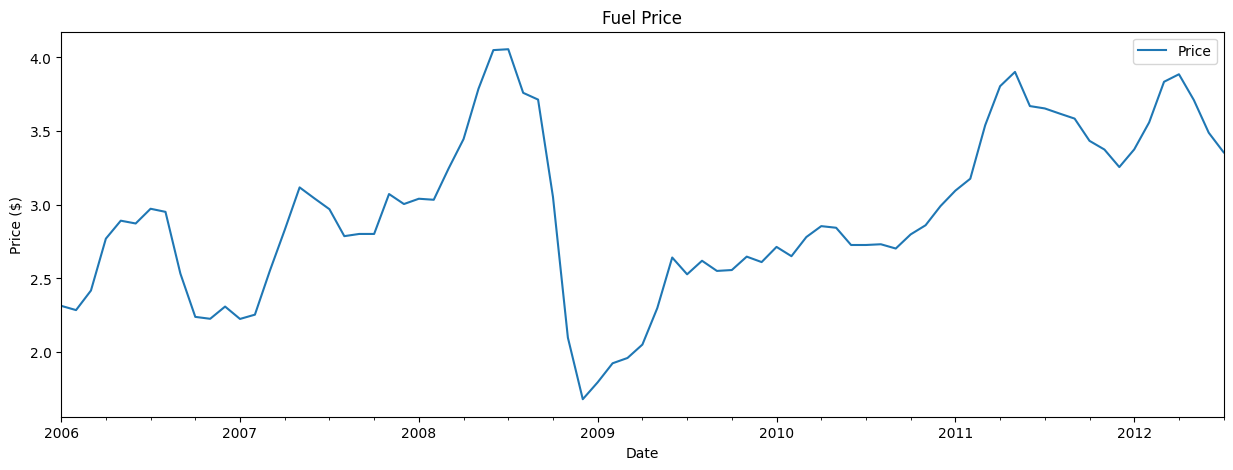

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(15, 5))
USRegular[['Price', 'Month_of_Price']].plot(ax=axs, x='Month_of_Price', y='Price')
axs.set_title('Fuel Price')
axs.set_xlabel('Date')
axs.set_ylabel('Price ($)')

#### Plotting multiple lines of price data, and using the 'label' attribute:

Text(0, 0.5, 'Price ($)')

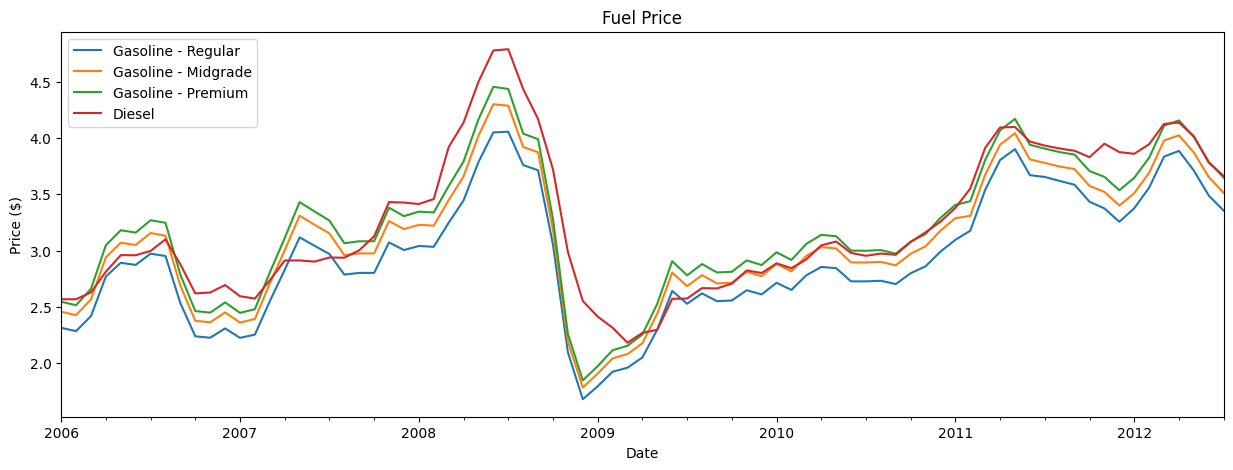

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(15, 5))

for fuelType in fuelPrices['Fuel'].unique():
    fuelPrices.loc[(fuelPrices['Fuel'] == fuelType) &
                   (fuelPrices['County'] == 'US'), :].plot(ax=axs, y='Price',
                                                           x='Month_of_Price',
                                                          label=fuelType)

axs.set_title('Fuel Price')
axs.set_xlabel('Date')
axs.set_ylabel('Price ($)')

<a name='histograms'></a>
# Plotting Histograms

Note that we use the plot() method again, but this time pass the 'hist' argument to the 'kind' argument.  Valid values of the kind attribute include:
* ‘bar’ or ‘barh’ for bar plots
* ‘hist’ for histogram
* ‘box’ for boxplot
* ‘kde’ or 'density' for density plots
* ‘area’ for area plots
* ‘scatter’ for scatter plots
* ‘hexbin’ for hexagonal bin plots
* ‘pie’ for pie plots

<Axes: ylabel='Frequency'>

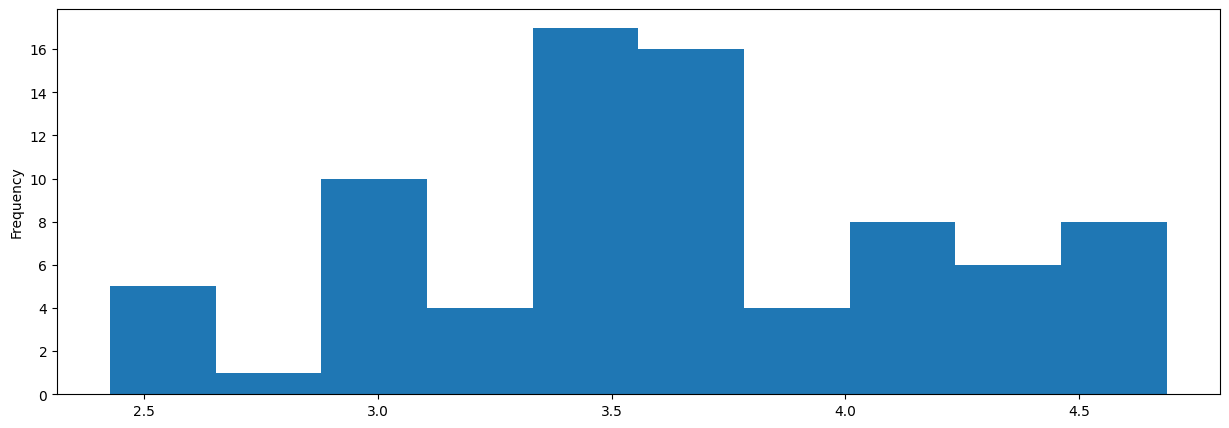

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(15, 5))
fuelPrices.loc[(fuelPrices['County']=='Honolulu') &
               (fuelPrices['Fuel']=='Gasoline - Premium'), 'Price'].plot(kind='hist', ax=axs)

#### Introducing the bins argument:

<Axes: ylabel='Frequency'>

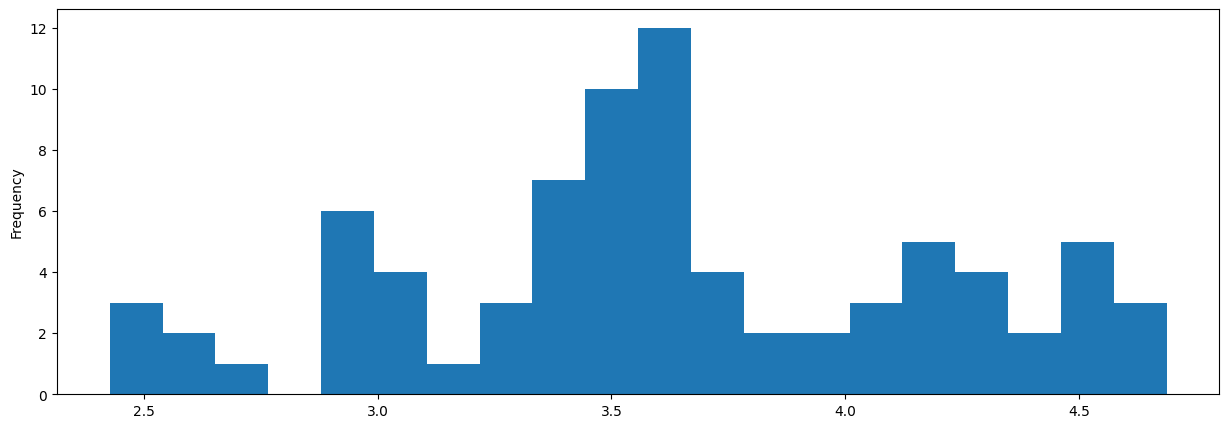

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(15, 5))
fuelPrices.loc[(fuelPrices['County']=='Honolulu') &
               (fuelPrices['Fuel']=='Gasoline - Premium'), 'Price'].plot(kind='hist', bins=20, ax=axs)

#### Introducing alpha and plotting multiple histograms:

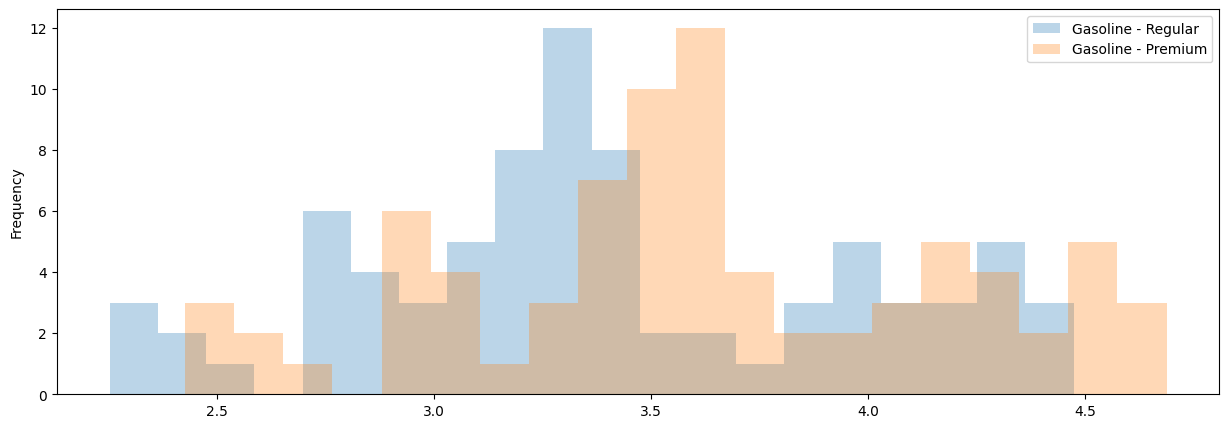

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(15, 5))
for fuelType in ['Gasoline - Regular', 'Gasoline - Premium']:
    fuelPrices.loc[(fuelPrices['County']=='Honolulu') &
                   (fuelPrices['Fuel']==fuelType),
                   'Price'].plot(kind='hist', bins=20, ax=axs, alpha=0.3, label=fuelType)
    axs.legend()

<a name=barcharts></a>
# Bar Charts

For bar charts, let's use our labor sheet data. First, we load the data:

In [ ]:
filepath = ('../Data/LaborSheetData.csv')
laborSheetData = pd.read_csv(filepath, parse_dates=[[2, 3], 13])
laborSheetData.head(2)

/tmp/ipykernel_976/3950084511.py:2: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  laborSheetData = pd.read_csv(filepath, parse_dates=[[2, 3], 13])


FileNotFoundError: [Errno 2] No such file or directory: '../Data/LaborSheetData.csv'

#### Plotting the mean hourly sales per store:

In [ ]:
meanHourlySales = laborSheetData.groupby('Store')['Sales'].mean()
print(meanHourlySales)
fig, axs = plt.subplots(1, 1, figsize=(15, 5))
meanHourlySales.plot(kind='bar', ax=axs)

#### Create plots of sales per manager, per store:

First let's look at an example of zip. I discuss this in the lecture.

In [ ]:
for A, B in zip([1, 2, 3], ['a', 'b', 'c']):
    print(A, B)

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(15, 8))

for store, ax in zip(laborSheetData['Store'].unique(), axs.flatten()):

    # laborSheetData.loc[laborSheetData['Store']==store, :].groupby('Manager')['Sales'].mean().plot(ax=ax)
    storeSubset = laborSheetData.loc[laborSheetData['Store']==store, :]
    managerHourlyMeanSales = storeSubset.groupby('Manager')['Sales'].mean()
    managerHourlyMeanSales.plot(ax=ax, kind='bar')

fig.tight_layout()


---

# Additional Students' Practice and Answer Key

These practice questions are designed for undergraduate students. Try the **Student Practice** cell first, then compare your work with the **Completed Answer** cell.


## Student Practice 1: Matplotlib Bar Chart
Create a bar chart showing average score by class. Add a title and axis labels.

## Student Practice 2: Seaborn Scatter Plot
Create a scatter plot showing the relationship between hours studied and exam score.

In [ ]:
# Completed Answer: Visualization Practice
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.DataFrame({
    'class_name': ['A', 'A', 'B', 'B', 'C', 'C'],
    'hours_studied': [2, 4, 3, 5, 1, 6],
    'score': [70, 85, 78, 90, 65, 95]
})

avg_by_class = df.groupby('class_name')['score'].mean().reset_index()

plt.figure(figsize=(6, 4))
plt.bar(avg_by_class['class_name'], avg_by_class['score'])
plt.title('Average Score by Class')
plt.xlabel('Class')
plt.ylabel('Average Score')
plt.show()

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='hours_studied', y='score')
plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.show()